In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/cybersecurity_attacks.csv')

# First look at the data
print(df.shape)
print(df.head())

(40000, 25)
             Timestamp Source IP Address Destination IP Address  Source Port  \
0  2023-05-30 06:33:58     103.216.15.12           84.9.164.252        31225   
1  2020-08-26 07:08:30    78.199.217.198         66.191.137.154        17245   
2  2022-11-13 08:23:25      63.79.210.48          198.219.82.17        16811   
3  2023-07-02 10:38:46     163.42.196.10        101.228.192.255        20018   
4  2023-07-16 13:11:07     71.166.185.76        189.243.174.238         6131   

   Destination Port Protocol  Packet Length Packet Type Traffic Type  \
0             17616     ICMP            503        Data         HTTP   
1             48166     ICMP           1174        Data         HTTP   
2             53600      UDP            306     Control         HTTP   
3             32534      UDP            385        Data         HTTP   
4             26646      TCP           1462        Data          DNS   

                                        Payload Data  ... Action Taken  \


In [3]:
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

['Timestamp', 'Source IP Address', 'Destination IP Address', 'Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']

Missing values:
Timestamp                     0
Source IP Address             0
Destination IP Address        0
Source Port                   0
Destination Port              0
Protocol                      0
Packet Length                 0
Packet Type                   0
Traffic Type                  0
Payload Data                  0
Malware Indicators        20000
Anomaly Scores                0
Alerts/Warnings           20067
Attack Type                   0
Attack Signature              0
Action Taken                  0
Severity Level     

In [4]:
# Most common attack types
attack_counts = df['Attack Type'].value_counts()
print(attack_counts)

Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64


C:\Users\maari\AppData\Local\Temp\ipykernel_11148\2408146799.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attack Type', palette='Reds_r')


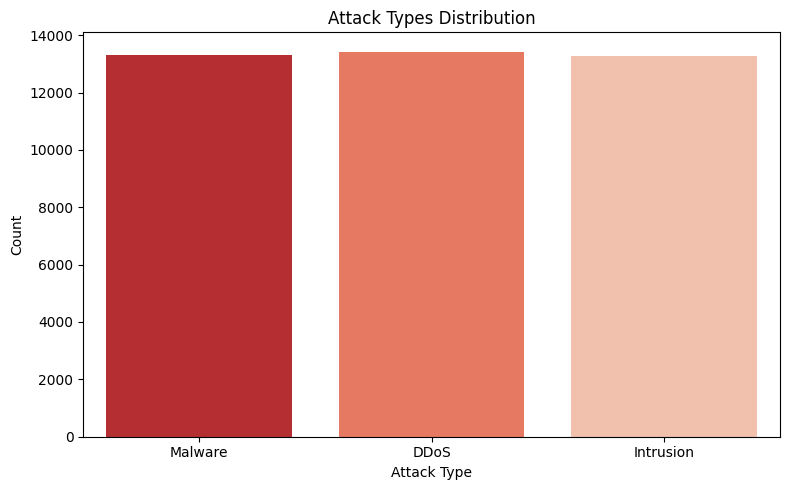

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Attack Type', palette='Reds_r')
plt.title('Attack Types Distribution')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../screenshots/attack_types.png')
plt.show()

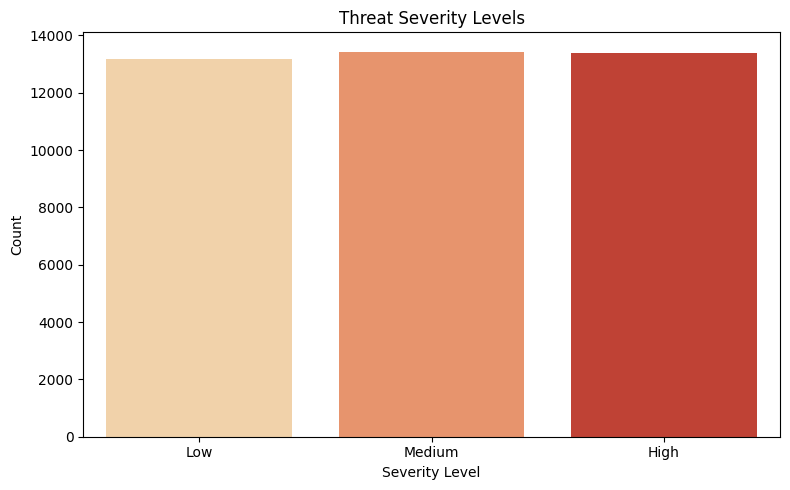

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Severity Level', hue='Severity Level', palette='OrRd', legend=False)
plt.title('Threat Severity Levels')
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../screenshots/severity_levels.png')
plt.show()

In [7]:
plt.savefig('../screenshots/severity_levels.png')

<Figure size 640x480 with 0 Axes>

In [8]:
plt.show()

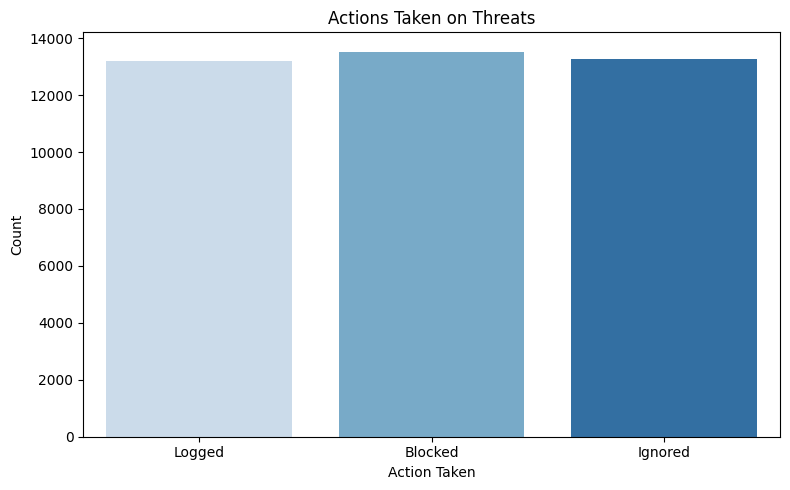

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Action Taken', hue='Action Taken', palette='Blues', legend=False)
plt.title('Actions Taken on Threats')
plt.xlabel('Action Taken')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../screenshots/action_taken.png')
plt.show()

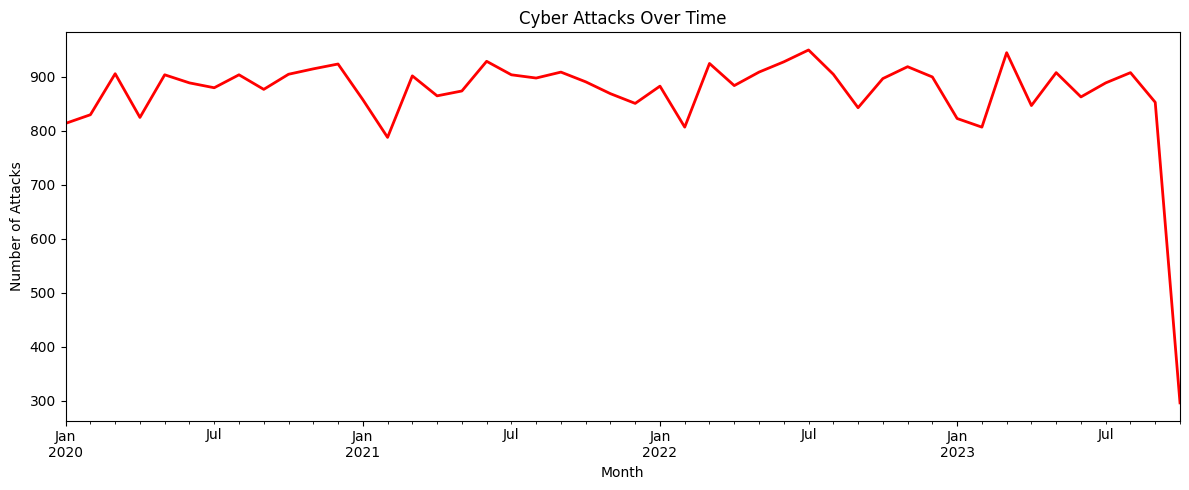

In [10]:
# Convert Timestamp to datetime format
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Group by month
df['Month'] = df['Timestamp'].dt.to_period('M')
monthly_attacks = df.groupby('Month').size()

# Plot
plt.figure(figsize=(12, 5))
monthly_attacks.plot(kind='line', color='red', linewidth=2)
plt.title('Cyber Attacks Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Attacks')
plt.tight_layout()
plt.savefig('../screenshots/attacks_over_time.png')
plt.show()

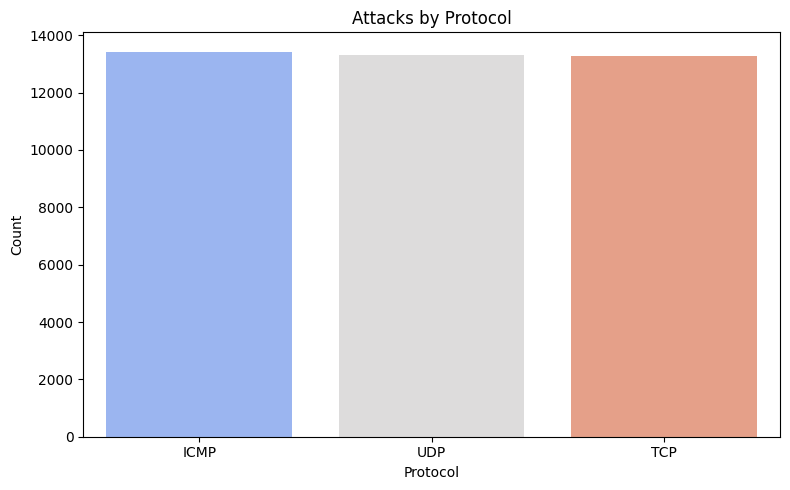

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Protocol', hue='Protocol', palette='coolwarm', legend=False)
plt.title('Attacks by Protocol')
plt.xlabel('Protocol')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../screenshots/protocol_breakdown.png')
plt.show()

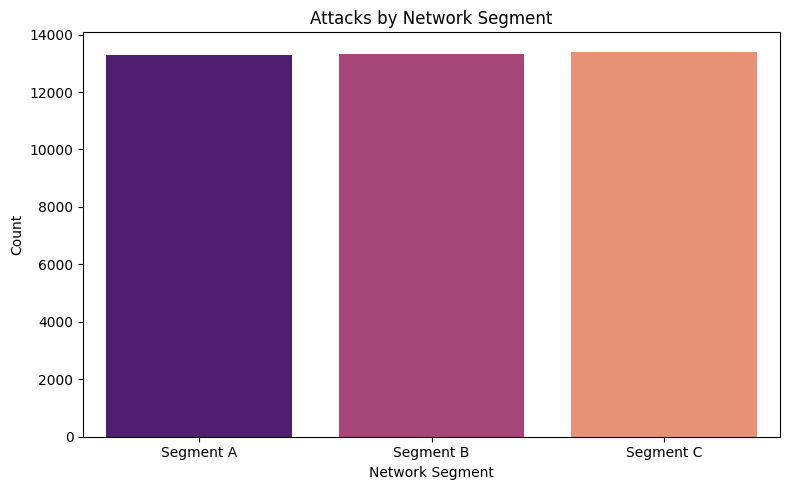

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Network Segment', hue='Network Segment', palette='magma', legend=False)
plt.title('Attacks by Network Segment')
plt.xlabel('Network Segment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../screenshots/network_segments.png')
plt.show()

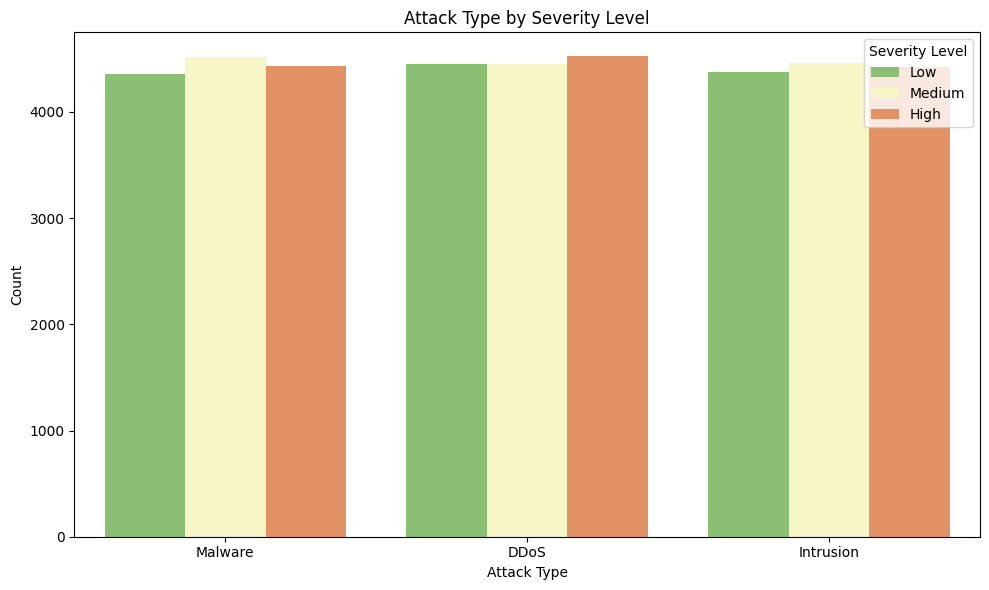

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Attack Type', hue='Severity Level', palette='RdYlGn_r')
plt.title('Attack Type by Severity Level')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.legend(title='Severity Level')
plt.tight_layout()
plt.savefig('../screenshots/attack_severity.png')
plt.show()

In [14]:
# Select the most useful columns for Power BI
df_powerbi = df[['Timestamp', 'Attack Type', 'Severity Level', 
                  'Action Taken', 'Protocol', 'Network Segment', 
                  'Traffic Type', 'Log Source', 'Anomaly Scores',
                  'Source IP Address', 'Destination IP Address']]

# Save it
df_powerbi.to_csv('../data/cleaned_threats.csv', index=False)
print("Done! File saved.")

Done! File saved.
